In [1]:
import os
import time
import requests
import pandas as pd
from zipfile import ZipFile
from io import BytesIO
# Create log and square root transformations
import numpy as np
import plotly.express as px
import plotly.io as pio
# Robinson projection with log scale - using binned categories for better visibility
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
combined_consolidated_df = pd.read_csv("df_final.csv")

In [4]:
# Detailed column stats sorted by non-null count (descending)
col_stats = pd.DataFrame({
    'non_null_count': combined_consolidated_df.notna().sum(),
    'null_count': combined_consolidated_df.isna().sum(),
    'unique_count': combined_consolidated_df.nunique(dropna=True)
}).sort_values('non_null_count', ascending=False)



In [5]:
combined_consolidated_df['surveyyear'].value_counts()

surveyyear
2018    98855
2023    89184
2019    88883
2021    83439
2022    73268
2024    65437
2020    64461
2016    56030
2017    51392
2025    49191
2015    26086
2013     9742
2014     7643
2012     6243
2011     2813
Name: count, dtype: int64

In [6]:
# Add percent of total rows for nulls (rounded to 2 decimals)
total_rows = combined_consolidated_df.shape[0]
col_stats['null_pct'] = (col_stats['null_count'] / total_rows * 100).round(2)

In [7]:
col_stats.head(50)

,non_null_count,null_count,unique_count,null_pct
Unnamed: 0,772667,0,772667,0.00
surveyyear,772667,0,15,0.00
country,722176,50491,265,6.53
employment,704030,68637,228,8.88
education,686474,86193,12,11.16
years_coding,637461,135206,78,17.50
age,624959,147708,87,19.12
programming_experience,582775,189892,203,24.58
developer_type,566711,205956,18,26.66
company_size,541577,231090,38,29.91


In [8]:
print(sorted(combined_consolidated_df['surveyyear'].dropna().unique()))

[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


### Analyze by Country

#### Trend over time

In [9]:
# extract surveyyear and country and make a counts matrix
cols = ['surveyyear', 'country']
df_sub = combined_consolidated_df[cols].copy()

# drop rows missing either value
#df_sub = df_sub.dropna(subset=['surveyyear', 'country'])

# ensure surveyyear is treated consistently (optional)
# df_sub['surveyyear'] = df_sub['surveyyear'].astype(str)

# Create matrix: rows = surveyyear, cols = country, values = counts
matrix_df = pd.crosstab(df_sub['surveyyear'], df_sub['country']).sort_index()

# display and optionally save
display(matrix_df)


country,Afghanistan,Africa,Aland Islands,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antarctica,Antigua & Deps,Antigua and Barbuda,Argentina,Armenia,Aruba,Australasia,Australia,Austria,Azerbaidjan,Azerbaijan,Bahamas,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bermuda,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Bouvet Island,Brazil,British Indian Ocean Territory,Brunei Darussalam,Bulgaria,Burkina,Burkina Faso,Burundi,Cambodia,Cameroon,Canada,Cape Verde,Cayman Islands,Central African Rep,Central African Republic,Central America,Chad,Chile,China,Christmas Island,Colombia,Comoros,"Congo, Republic of the...",Cook Islands,Costa Rica,Croatia,Cuba,Cyprus,Czech Republic,Côte d'Ivoire,Democratic People's Republic of Korea,Democratic Republic of the Congo,Denmark,Djibouti,Dominica,Dominican Republic,East Timor,Ecuador,Egypt,El Salvador,Equatorial Guinea,Eritrea,Estonia,Ethiopia,Falkland Islands,Fiji,Finland,France,French Guyana,Gabon,Gambia,Georgia,Germany,Ghana,Gibraltar,Greece,Grenada,Guam,Guatemala,Guinea,Guyana,Haiti,Heard and McDonald Islands,Honduras,Hong Kong,Hungary,I prefer not to say,Iceland,India,Indonesia,Iran,"Iran, Islamic Republic of...",Iraq,Ireland,Isle of Man,Israel,Italy,Ivory Coast,Ivory Coast (Cote D'Ivoire),Jamaica,Japan,Jordan,Kazakhstan,Kenya,Kiribati,Kosovo,Kuwait,Kyrgyzstan,Laos,Latvia,Lebanon,Lesotho,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Macau,Macedonia,Macedonia [FYROM],Madagascar,Malawi,Malaysia,Maldives,Mali,Malta,Marshall Islands,Martinique (French),Mauritania,Mauritius,Mexico,Micronesia,"Micronesia, Federated States of...",Middle East,Moldavia,Moldova,Monaco,Mongolia,Montenegro,Montserrat,Morocco,Mozambique,Myanmar,Myanmar [Burma],Namibia,Nauru,Nepal,Netherlands,Netherlands Antilles,New Caledonia (French),New Zealand,Nicaragua,Niger,Nigeria,Nomadic,North America (Other),North Korea,Northern Mariana Islands,Norway,Oman,Other,Other Asia,Other Europe,Pakistan,Palau,Palestine,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Pitcairn Island,Poland,Polynesia (French),Portugal,Puerto Rico,Qatar,Republic of Moldova,Republic of North Macedonia,Reunion (French),Romania,Russia,Russian Federation,Rwanda,S. Georgia & S. Sandwich Isls.,Saint Helena,Saint Kitts and Nevis,Saint Lucia,Saint Vincent & Grenadines,Saint Vincent and the Grenadines,Samoa,San Marino,Sao Tome & Principe,Sao Tome and Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Slovak Republic,Slovakia,Slovenia,Solomon Islands,Somalia,South Africa,South America,South Korea,Spain,Sri Lanka,St Kitts & Nevis,Sudan,Suriname,Swaziland,Sweden,Switzerland,Syria,Tadjikistan,Taiwan,Tajikistan,Tanzania,Thailand,The former Yugoslav Republic of Macedonia,Timor-Leste,Togo,Tonga,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Tuvalu,U.S. Minor Outlying Islands,Uganda,Ukraine,United Arab Emirates,United Kingdom,United Republic of Tanzania,United States,Uruguay,Uzbekistan,Vanuatu,Vatican,Vatican City,Venezuela,"Venezuela, Bolivarian Republic of...",Vietnam,Virgin Islands (British),Virgin Islands (USA),Yemen,Zaire,Zambia,Zimbabwe
surveyyear,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2011,0,43,0,0,0,0,0,0,0,0,0,0,0,0,0,29,112,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,156,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,60,0,0,0,0,106,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,95,0,0,0,0,0,0,0,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,0,0,73,0,0,0,0,0,0,0,0,0,0,0,0,0,55,0,0,0,0,0,0,0,8,0,0,0,0,0,81,451,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,91,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,314,0,1037,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2012,0,92,0,0,0,0,0,0,0,0,0,0,0,0,0,105,185,0,0,0,0,0,15,0,0,0,0,0,0,

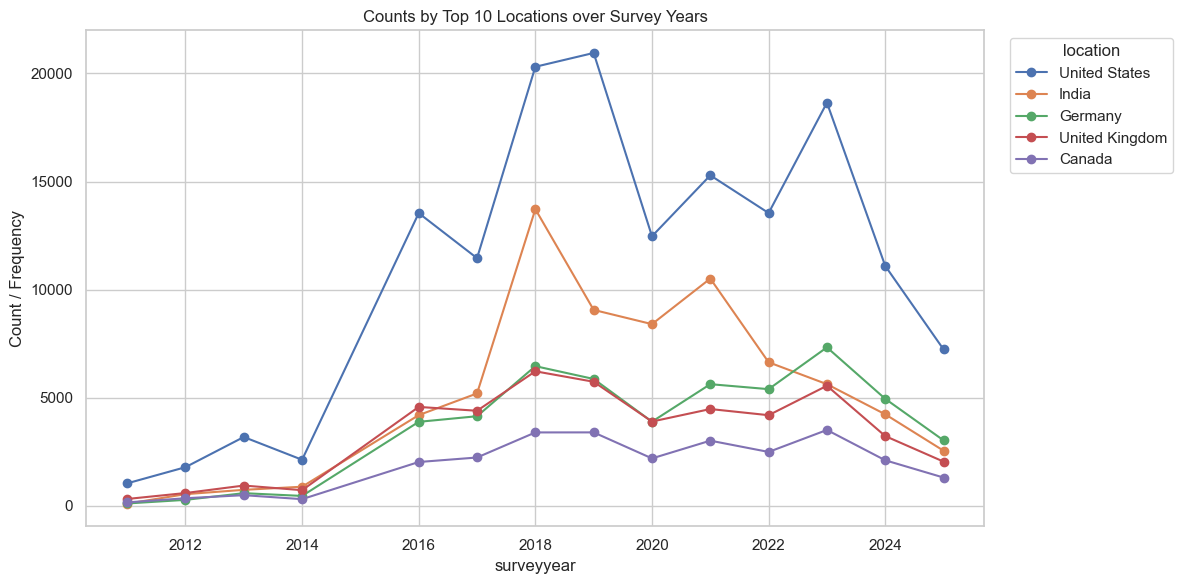

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# prepare a plotting-friendly copy (try numeric years first, otherwise keep strings)
matrix_plot = matrix_df.copy()
years_numeric = pd.to_numeric(matrix_plot.index, errors='coerce')
if years_numeric.notna().all():
    matrix_plot.index = years_numeric
matrix_plot = matrix_plot.sort_index()

# Select top 10 countries by total count
top_countries = matrix_plot.sum(axis=0).sort_values(ascending=False).head(5).index
matrix_plot_top = matrix_plot[top_countries]

sns.set(style='whitegrid')
ax = matrix_plot_top.plot(kind='line', figsize=(12,6), marker='o', linewidth=1.5)
ax.set_xlabel('surveyyear')
ax.set_ylabel('Count / Frequency')
ax.set_title('Counts by Top 10 Locations over Survey Years')
ax.legend(title='location', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Save and show
plt.show()


#### Overall by country

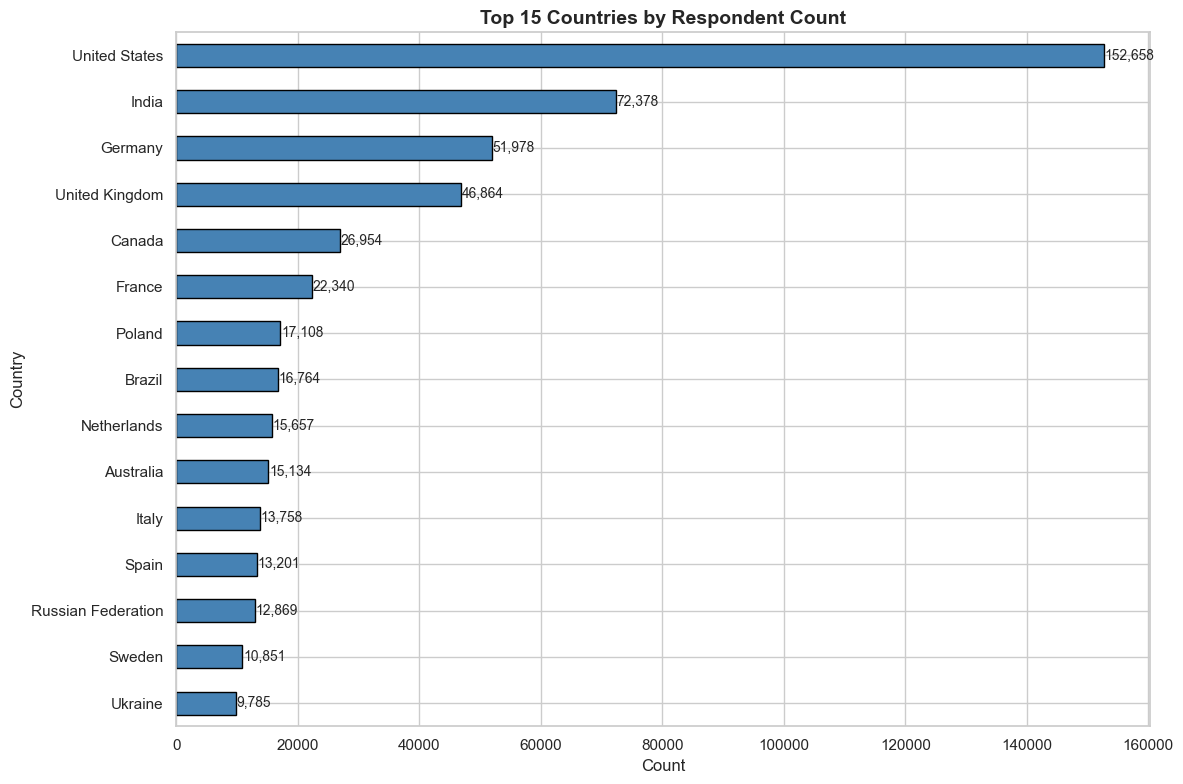

In [11]:
# Get country counts and select top 15
country_counts = combined_consolidated_df['country'].value_counts().head(15)

# Create bar chart
plt.figure(figsize=(12, 8))
sns.set(style='whitegrid')

ax = country_counts.plot(kind='barh', color='steelblue', edgecolor='black')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Top 15 Countries by Respondent Count', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Highest count at the top

# Add value labels on bars
for i, v in enumerate(country_counts.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Education Analysis

#### Trend for Education

In [12]:
# Create education by survey year matrix
cols = ['surveyyear', 'education']
df_edu = combined_consolidated_df[cols].copy()

# Create matrix: rows = surveyyear, cols = education, values = counts
education_matrix = pd.crosstab(df_edu['surveyyear'], df_edu['education']).sort_index()

display(education_matrix)

education,Professional degree,associate degree,bachelors,doctoral degree,i prefer not to say,less than college,masters,none,on the job training,other program,self-taught,some college
surveyyear,,,,,,,,,,,,
2016,0,0,18758,223,0,0,5370,0,932,408,18490,774
2017,715,0,29738,1308,1109,6955,11141,426,0,0,0,0
2018,0,2970,43659,3661,0,10607,21396,700,0,0,0,11710
2019,0,2938,39134,3630,0,10064,19569,553,0,0,0,10502
2020,0,1843,26542,2490,0,5712,13112,493,0,0,0,7239
2021,0,2231,35357,3823,0,12013,17512,0,0,1601,0,10589
2022,0,2236,30276,3290,0,9710,15486,0,0,1247,0,9326
2023,0,2807,36706,3887,0,10802,20543,0,0,1475,0,11753
2024,0,1793,24942,2970,0,6939,15557,0,0,932,0,7651


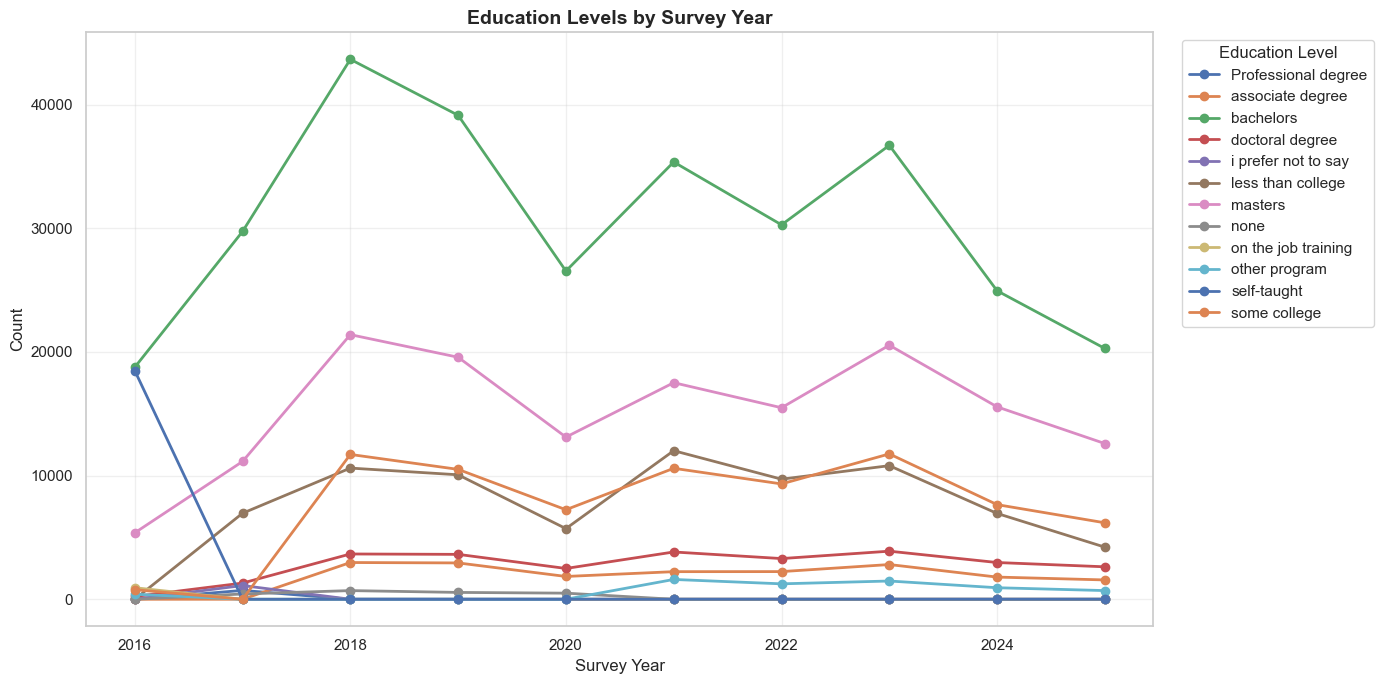

In [13]:
# Create line chart for education levels over time
education_plot = education_matrix.copy()

# Convert years to numeric if possible
years_numeric = pd.to_numeric(education_plot.index, errors='coerce')
#if years_numeric.notna().all():
#    education_plot.index = years_numeric
education_plot = education_plot.sort_index()

# Create the line chart
sns.set(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each education level
for col in education_plot.columns:
    ax.plot(education_plot.index, education_plot[col], marker='o', linewidth=2, label=col)

ax.set_xlabel('Survey Year', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Education Levels by Survey Year', fontsize=14, fontweight='bold')
ax.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Overall education

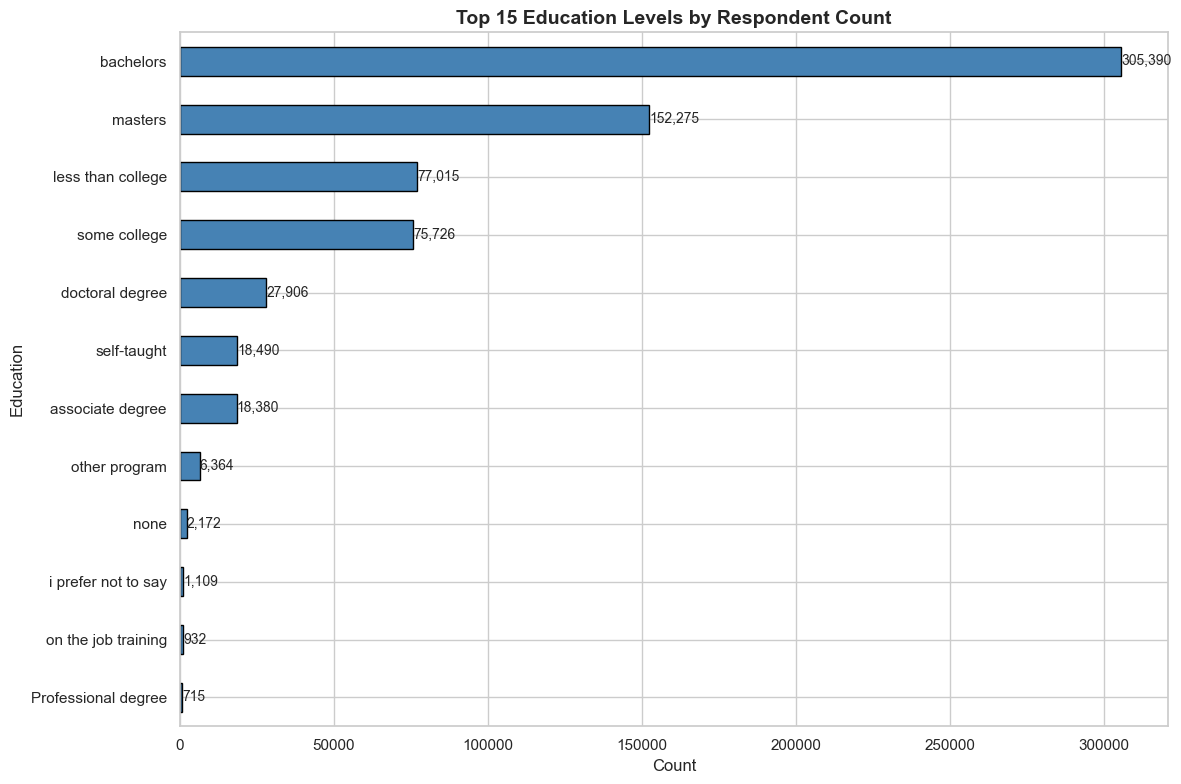

In [14]:
# Get country counts and select top 15
education_counts = combined_consolidated_df['education'].value_counts().head(15)

# Create bar chart
plt.figure(figsize=(12, 8))
sns.set(style='whitegrid')

ax = education_counts.plot(kind='barh', color='steelblue', edgecolor='black')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Education', fontsize=12)
ax.set_title('Top 15 Education Levels by Respondent Count', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Highest count at the top

# Add value labels on bars
for i, v in enumerate(education_counts.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Developer Type Analysis

#### Trend Analysis

In [29]:
# extract surveyyear and country and make a counts matrix
cols = ['surveyyear', 'developer_type']
df_dev = combined_consolidated_df[cols].copy()

# Create matrix: rows = surveyyear, cols = country, values = counts
matrix_df_dev = pd.crosstab(df_dev['surveyyear'], df_dev['developer_type']).sort_index()

# display and optionally save
display(matrix_df_dev)

developer_type,back-end developer,cyber security,data role,data scientist,design,educator,engineering role,executive,front-end developer,full-stack developer,marketing or sales professional,other developer,other role,product/project manager,research role,retired,student,systems administrator
surveyyear,,,,,,,,,,,,,,,,,,
2017,0,0,140,846,13,0,109,0,0,0,0,33730,1174,0,0,0,0,113
2018,53300,0,3794,2211,2691,0,912,1195,5432,7384,91,10505,0,186,792,0,3300,305
2019,25991,0,11831,3108,5184,180,630,274,4886,12017,89,9012,0,193,6095,0,1561,284
2020,18142,0,7278,1936,2963,83,310,118,3213,6100,52,5282,0,95,3638,0,0,160
2021,8121,0,2650,1937,120,150,741,362,13397,16477,85,17445,2374,224,1150,0,975,276
2022,10491,184,2497,3424,90,320,2100,289,15375,16664,76,5527,1358,365,686,0,1662,194
2023,13745,797,2342,1588,281,415,3782,1332,5071,25735,149,11723,3080,1035,3058,0,1996,743
2024,9928,591,1812,1024,182,355,2419,837,3349,18260,96,9259,2458,708,2513,0,5102,552
2025,6453,370,1296,574,0,0,2531,528,1974,12351,0,9351,2256,507,1543,458,3008,480


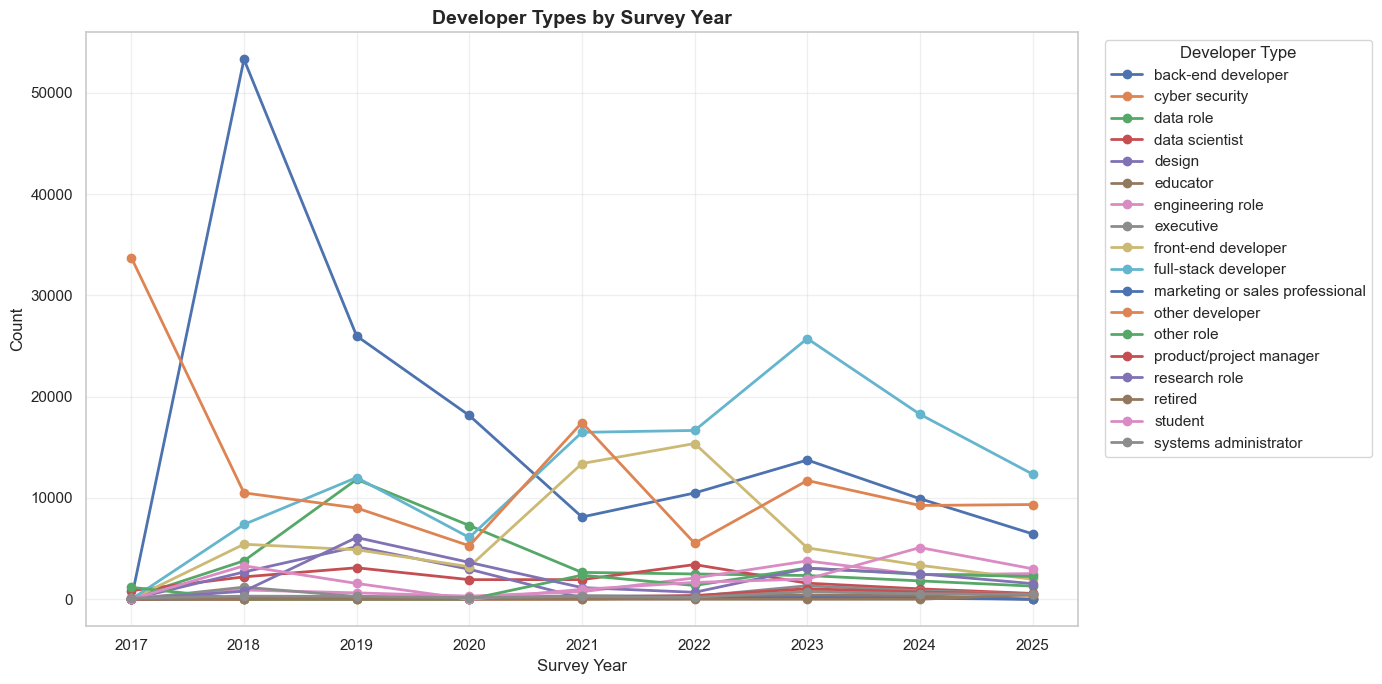

In [30]:
# Create line chart for education levels over time
dev_plot = matrix_df_dev.copy()

# Convert years to numeric if possible
years_numeric = pd.to_numeric(dev_plot.index, errors='coerce')
if years_numeric.notna().all():
    dev_plot.index = years_numeric
dev_plot = dev_plot.sort_index()

# Create the line chart
sns.set(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each education level
for col in dev_plot.columns:
    ax.plot(dev_plot.index, dev_plot[col], marker='o', linewidth=2, label=col)

ax.set_xlabel('Survey Year', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Developer Types by Survey Year', fontsize=14, fontweight='bold')
ax.legend(title='Developer Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Overall Analysis

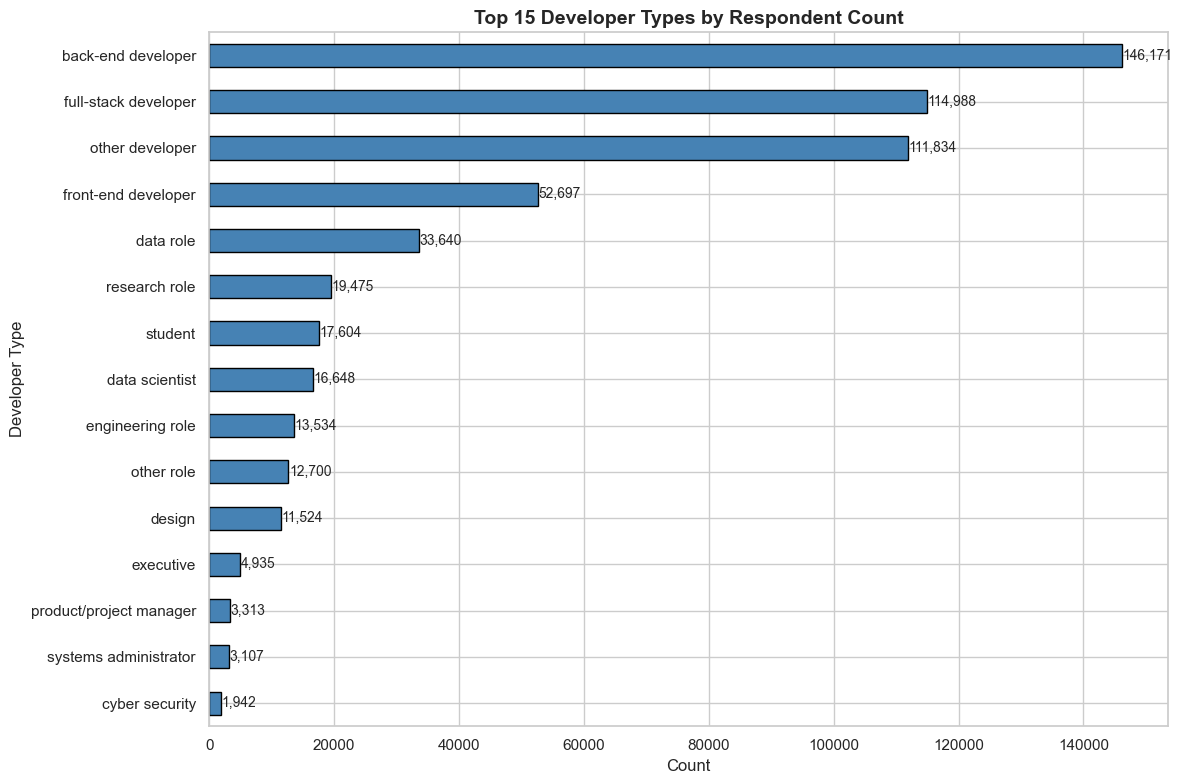

In [31]:
# Get country counts and select top 15
developer_counts = combined_consolidated_df['developer_type'].value_counts().head(15)

# Create bar chart
plt.figure(figsize=(12, 8))
sns.set(style='whitegrid')

ax = developer_counts.plot(kind='barh', color='steelblue', edgecolor='black')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Developer Type', fontsize=12)
ax.set_title('Top 15 Developer Types by Respondent Count', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Highest count at the top

# Add value labels on bars
for i, v in enumerate(developer_counts.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Regional Differences

#### Developer Type by Country

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Create developer type by country matrix for top countries
cols = ['country', 'developer_type']
df_country_dev = combined_consolidated_df[cols].dropna()

top_countries = df_country_dev['country'].value_counts().head(15).index

# Use same top 10 countries for consistency
df_country_dev_top = df_country_dev[df_country_dev['country'].isin(top_countries)]

# Create crosstab
country_dev_matrix = pd.crosstab(df_country_dev_top['country'], df_country_dev_top['developer_type'])

# Sort by total count (descending)
country_dev_matrix = country_dev_matrix.loc[country_dev_matrix.sum(axis=1).sort_values(ascending=False).index]

display(country_dev_matrix)

developer_type,back-end developer,cyber security,data role,data scientist,design,educator,engineering role,executive,front-end developer,full-stack developer,marketing or sales professional,other developer,other role,product/project manager,research role,retired,student,systems administrator
country,,,,,,,,,,,,,,,,,,
United States,27755,438,8303,3810,2641,407,3920,1280,9558,24926,174,21965,3454,661,3886,151,2994,725
India,15017,100,2657,1629,1562,67,712,282,6145,9505,29,11441,614,235,1228,6,2351,125
Germany,9797,142,2153,1272,623,89,891,316,3335,8079,31,8681,907,330,2071,15,1452,312
United Kingdom,9099,96,2241,1031,625,80,975,359,2688,7602,33,7250,985,145,977,52,732,193
Canada,4918,76,1216,561,428,61,590,214,1696,4522,24,4278,563,107,574,33,656,99
France,4171,77,871,663,210,59,453,192,1370,3883,11,3703,387,146,740,11,442,83
Brazil,4341,31,872,360,234,53,263,102,1336,3090,12,2242,233,80,640,3,359,60
Poland,4305,41,627,310,258,17,279,59,1185,2114,5,3065,227,39,276,4,378,75
Netherlands,3628,46,672,379,267,38,259,105,1124,2463,14,2094,284,52,411,7,318,38


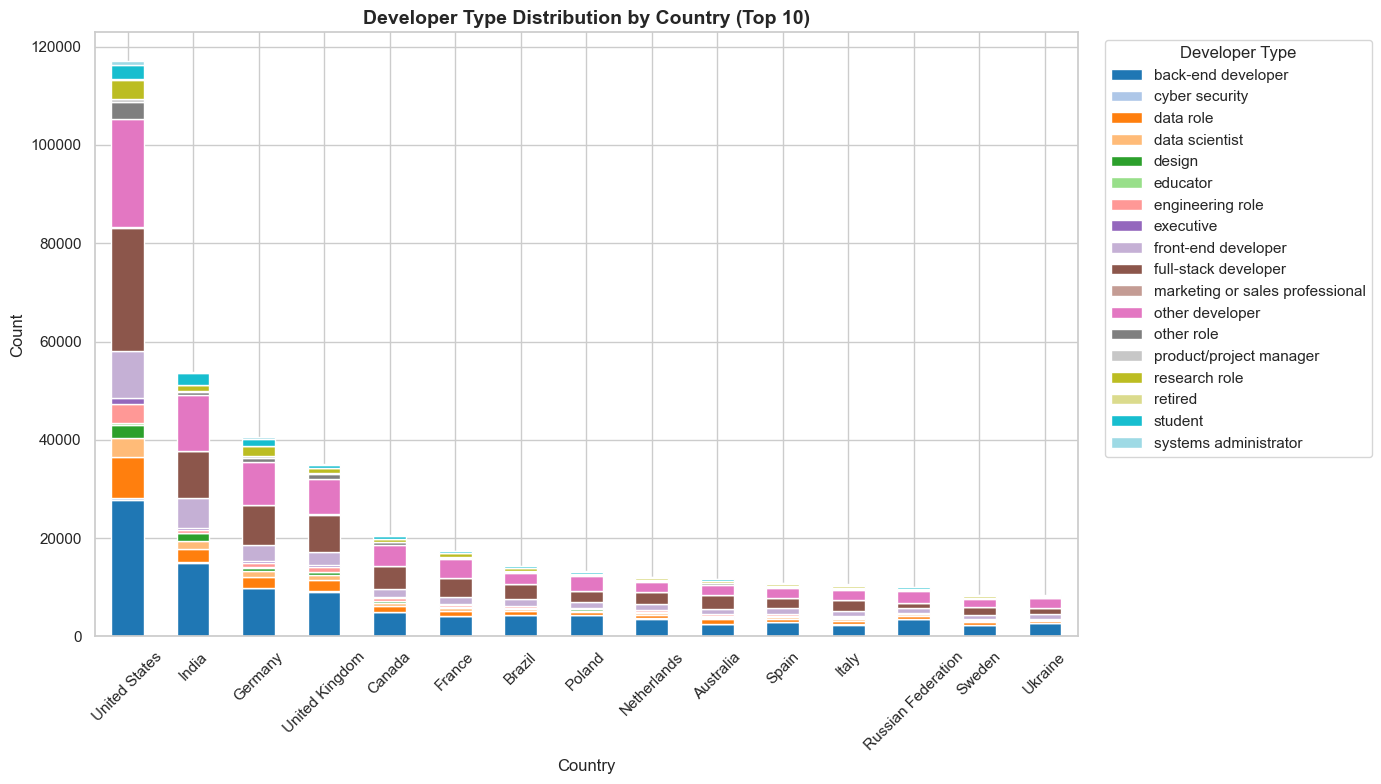

In [33]:
# Create stacked bar chart for developer type by country
fig, ax = plt.subplots(figsize=(14, 8))

country_dev_matrix.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Developer Type Distribution by Country (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Developer Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

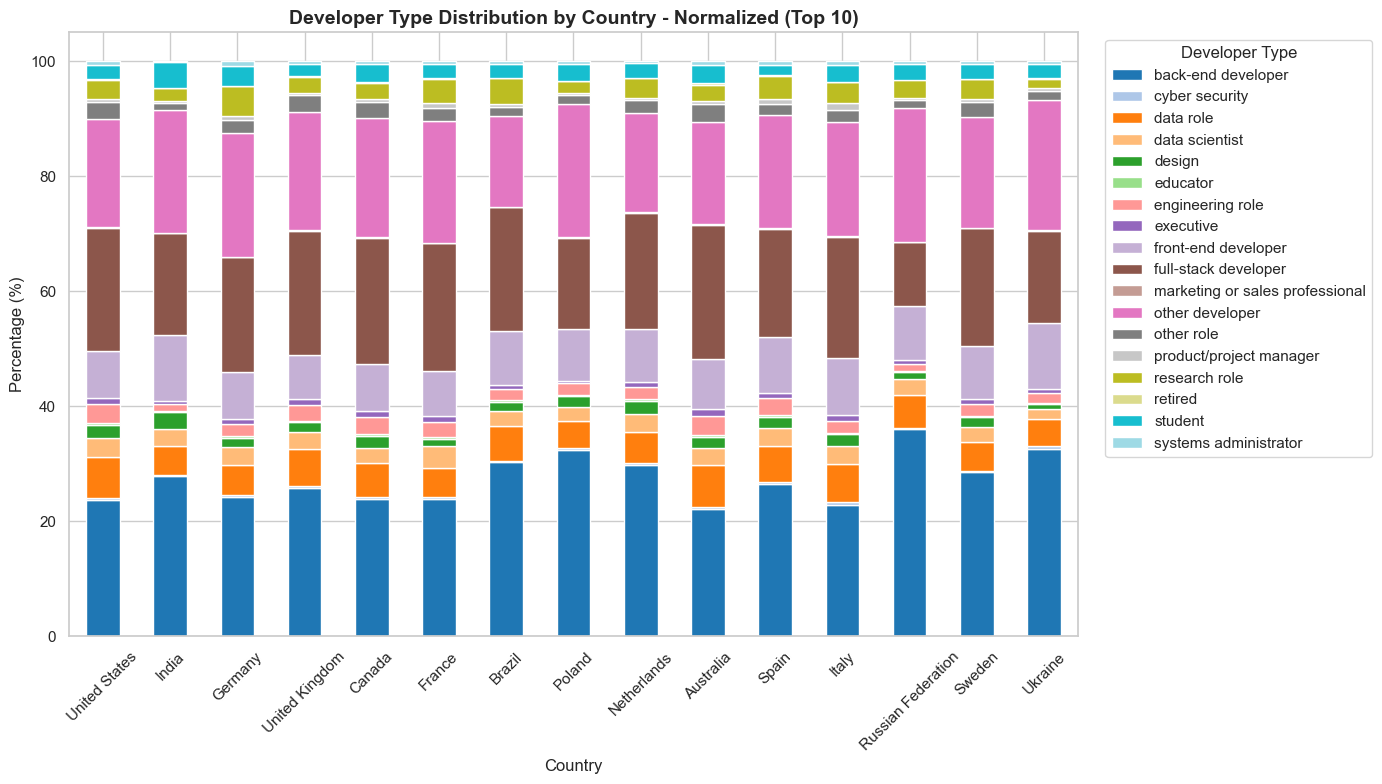

In [34]:
# Create normalized (percentage) view for developer type
country_dev_pct = country_dev_matrix.div(country_dev_matrix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))

country_dev_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Developer Type Distribution by Country - Normalized (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Developer Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

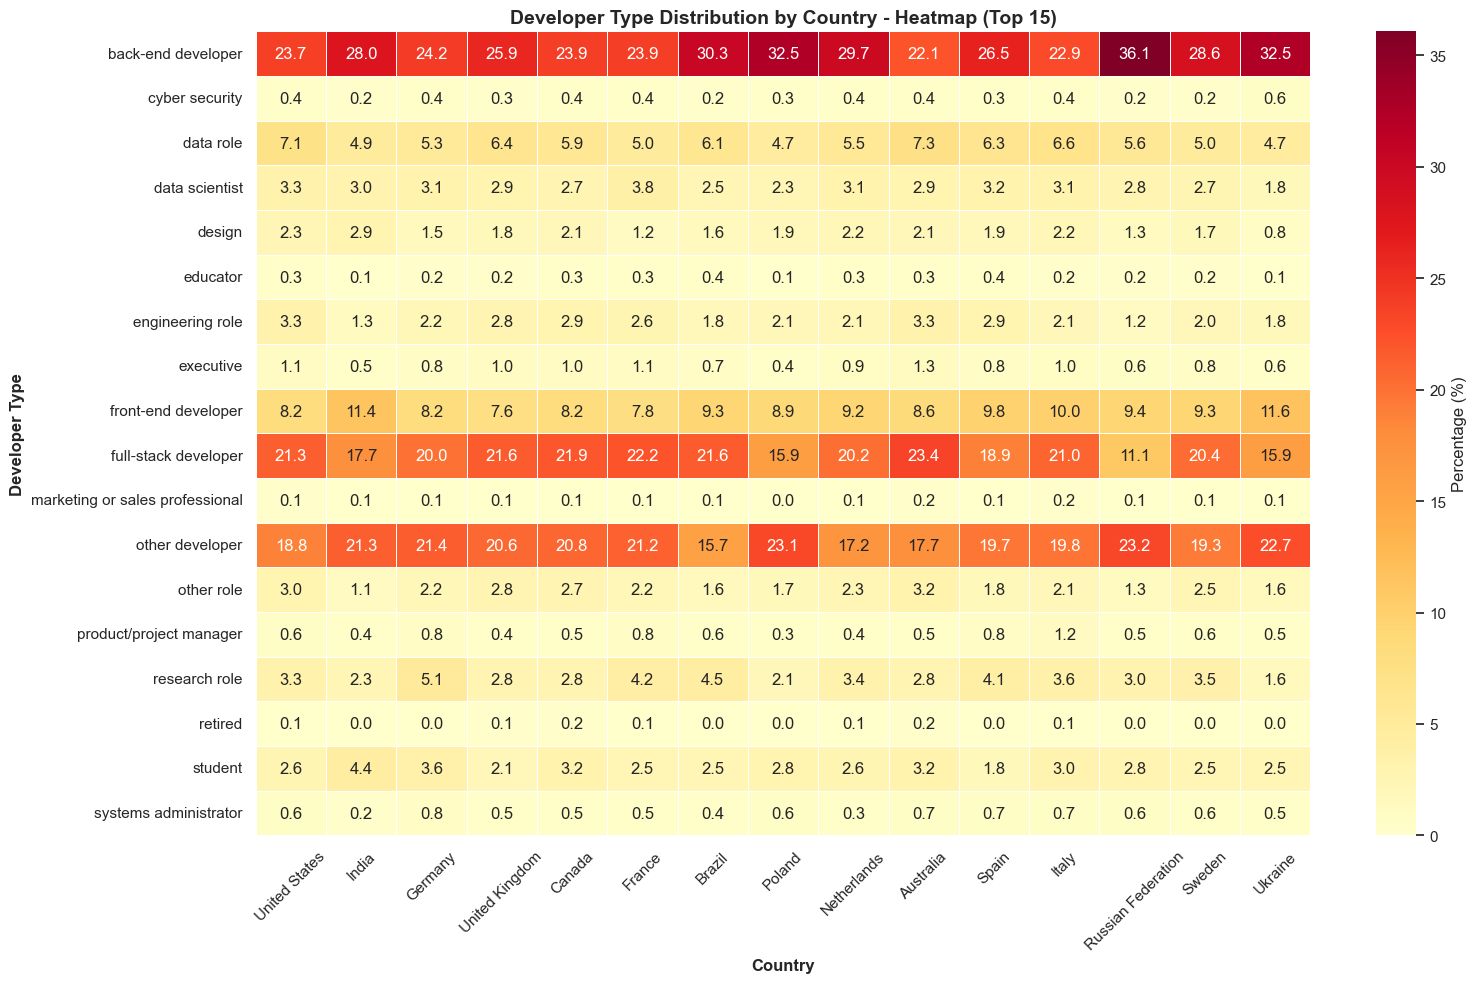

In [35]:
# Create heatmap for developer type by country
fig, ax = plt.subplots(figsize=(16, 10))

# Use normalized percentages for better comparison across countries
sns.heatmap(country_dev_pct.T, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax, linewidths=0.5)

ax.set_xlabel('Country', fontsize=12, fontweight='bold')
ax.set_ylabel('Developer Type', fontsize=12, fontweight='bold')
ax.set_title('Developer Type Distribution by Country - Heatmap (Top 15)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

#### Education by Country

In [36]:
# Create education by country matrix for top countries
cols = ['country', 'education']
df_country_edu = combined_consolidated_df[cols].dropna()

# Get top 15 countries by respondent count
top_countries = df_country_edu['country'].value_counts().head(15).index

# Get top 15 countries by respondent count
top_edu = df_country_edu['education'].value_counts().head(5).index

# Filter to top countries
df_country_edu_top = df_country_edu[df_country_edu['country'].isin(top_countries) & df_country_edu['education'].isin(top_edu)]

# Create crosstab
country_edu_matrix = pd.crosstab(df_country_edu_top['country'], df_country_edu_top['education'])

# Sort by total count (descending)
country_edu_matrix = country_edu_matrix.loc[country_edu_matrix.sum(axis=1).sort_values(ascending=False).index]

display(country_edu_matrix)

education,bachelors,doctoral degree,less than college,masters,some college
country,,,,,
United States,73663,5473,10506,23657,16125
India,40896,524,6334,13117,2561
Germany,13922,2723,9367,14708,4887
United Kingdom,19552,2359,4146,9007,5107
Canada,12219,747,2489,3453,3092
France,3816,1812,905,12225,1032
Poland,4880,339,2356,5802,1943
Brazil,7681,646,1862,2076,2631
Netherlands,6058,543,1716,3498,1612


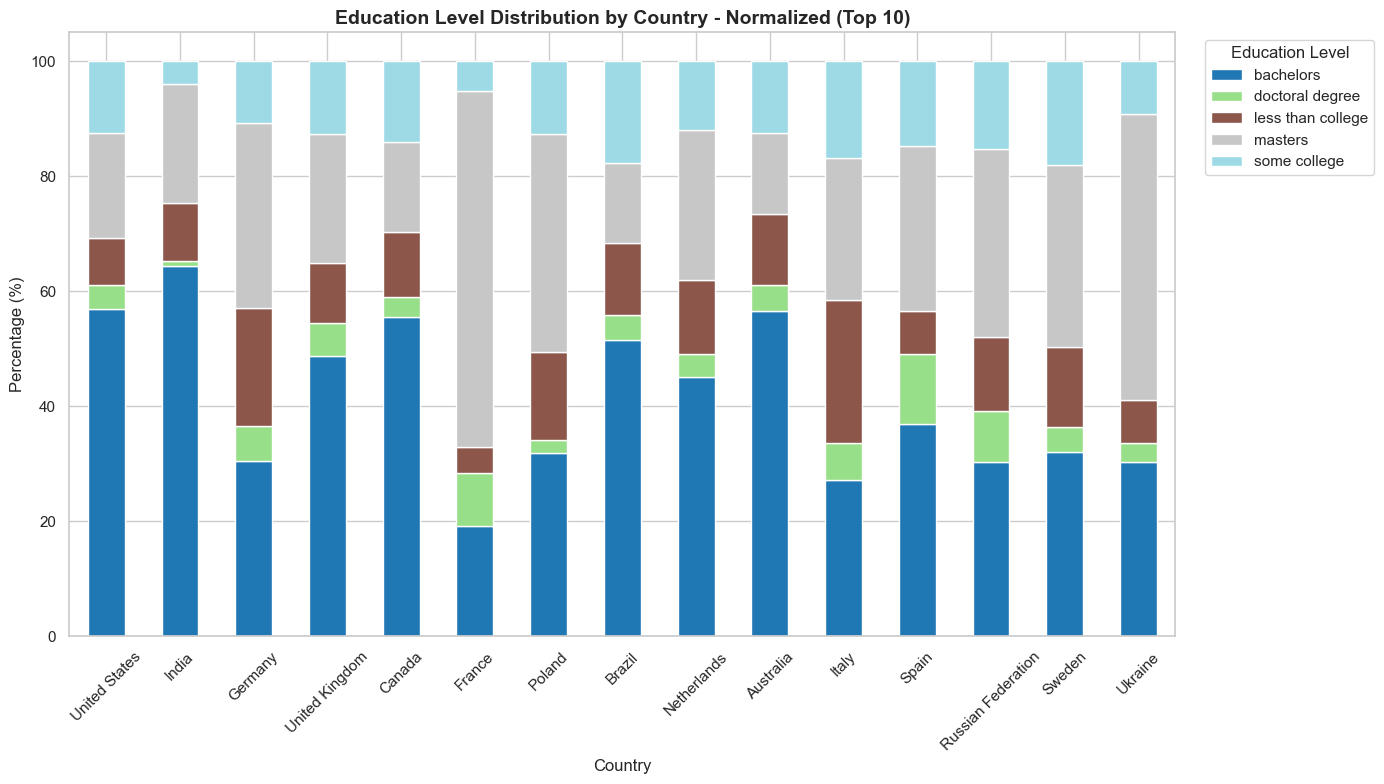

In [20]:
# Create normalized (percentage) view for better comparison
country_edu_pct = country_edu_matrix.div(country_edu_matrix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))

country_edu_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Education Level Distribution by Country - Normalized (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

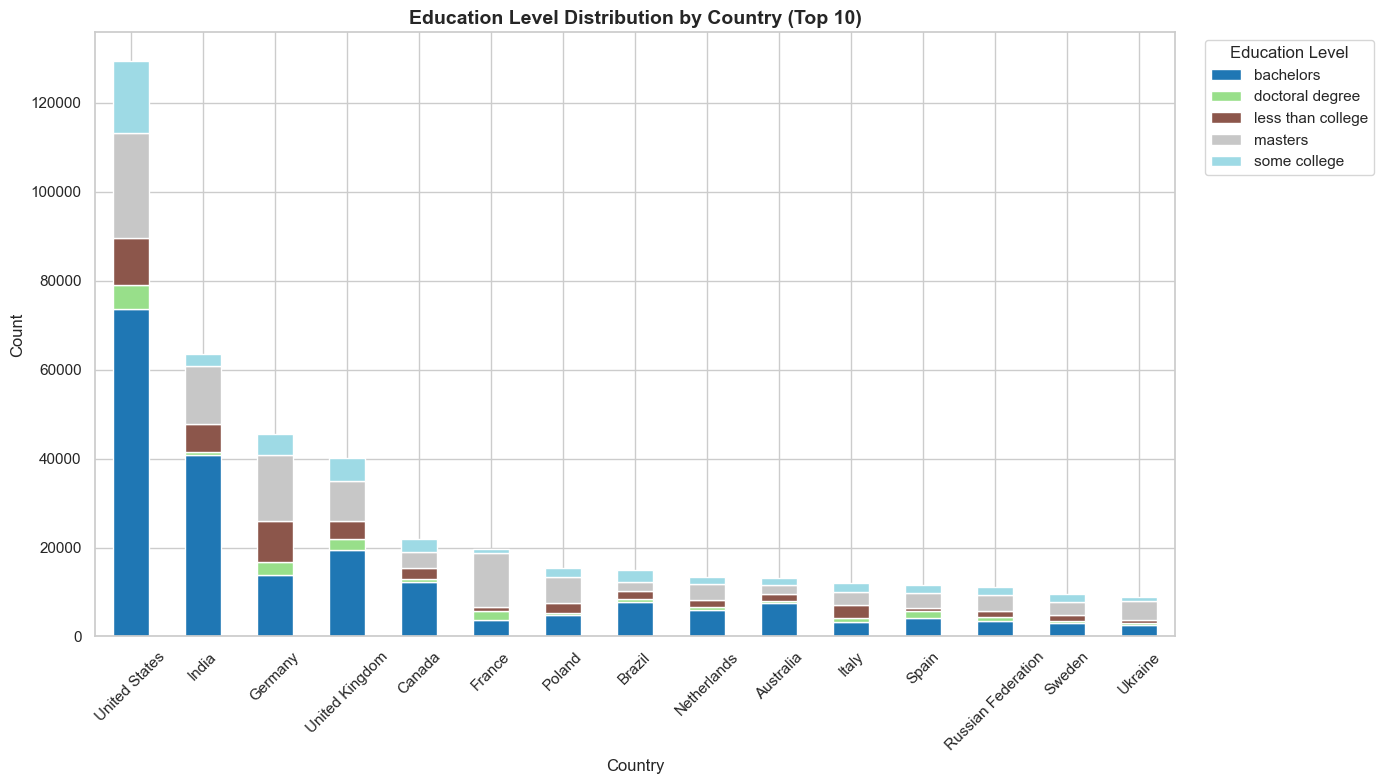

In [37]:
# Create stacked bar chart for education by country
fig, ax = plt.subplots(figsize=(14, 8))

country_edu_matrix.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Education Level Distribution by Country (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

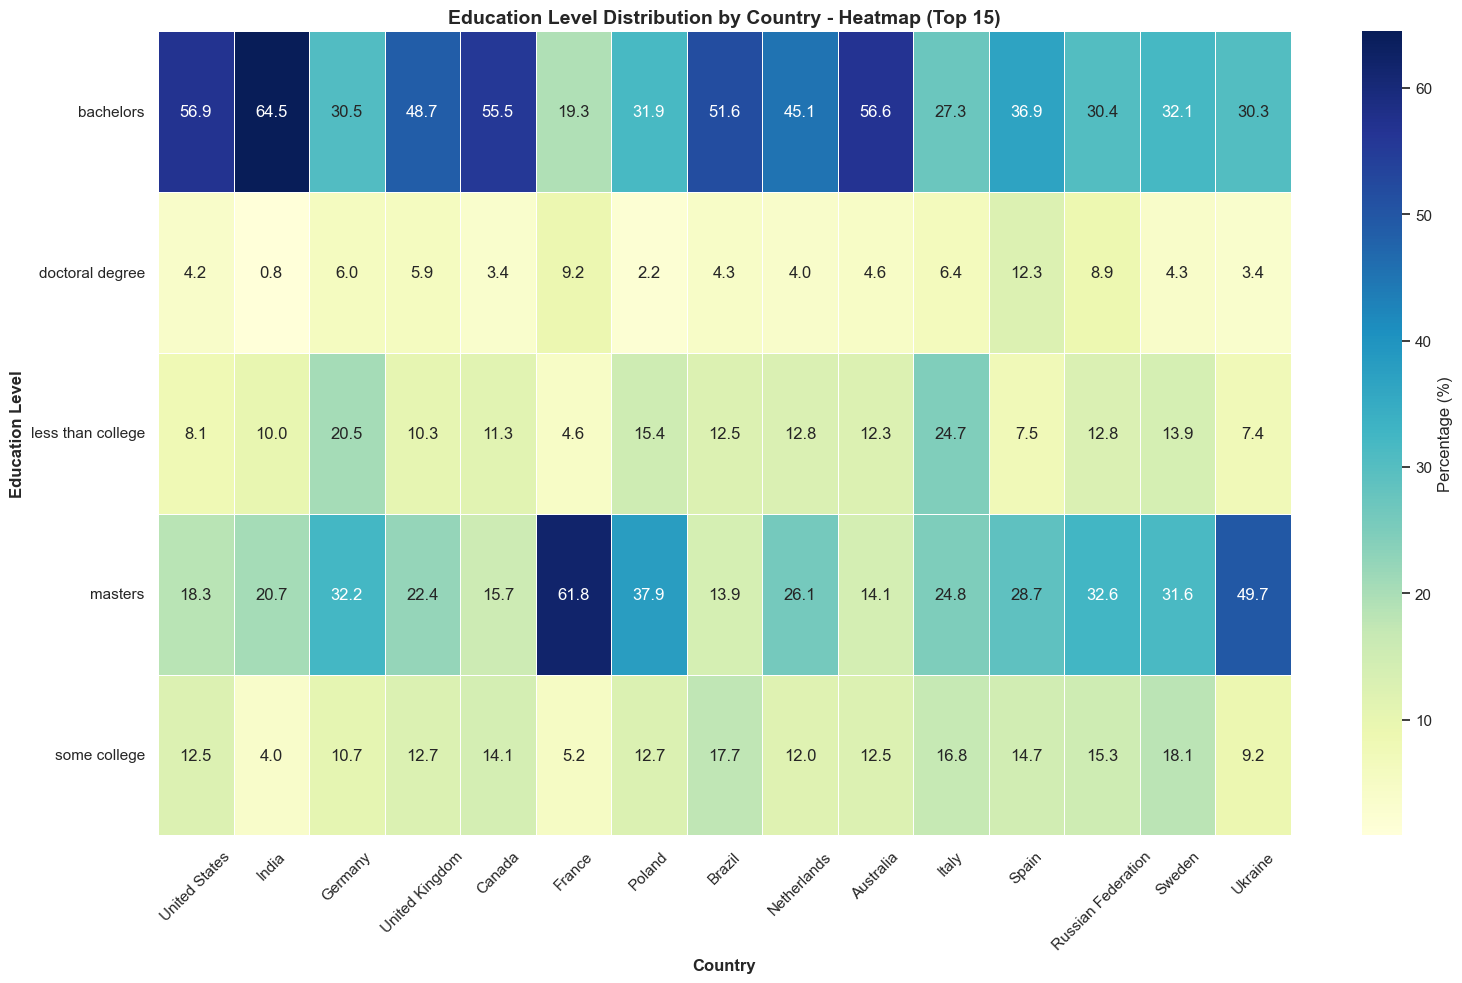

In [38]:
# Create heatmap for education by country
fig, ax = plt.subplots(figsize=(16, 10))

# Use normalized percentages for better comparison across countries
sns.heatmap(country_edu_pct.T, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax, linewidths=0.5)

ax.set_xlabel('Country', fontsize=12, fontweight='bold')
ax.set_ylabel('Education Level', fontsize=12, fontweight='bold')
ax.set_title('Education Level Distribution by Country - Heatmap (Top 15)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [39]:
# Identify all education levels present in the matrix
all_education_levels = country_edu_pct.columns.tolist()

# Define the levels to be explicitly plotted
education_levels_explicit = ['bachelors', 'masters']

# Identify 'other' education levels
education_levels_other = [col for col in all_education_levels if col not in education_levels_explicit]

# Create a new DataFrame for plotting
country_edu_pct_with_other = pd.DataFrame()
country_edu_pct_with_other['bachelors'] = country_edu_pct['bachelors']
country_edu_pct_with_other['masters'] = country_edu_pct['masters']

# Sum the 'other' education levels into a single 'other' column
if education_levels_other:
    country_edu_pct_with_other['other'] = country_edu_pct[education_levels_other].sum(axis=1)
else:
    country_edu_pct_with_other['other'] = 0 # If no other categories, set to 0

# Ensure percentages sum to 100% for verification (optional, but good practice)
# This re-normalizes just in case there were minor floating point discrepancies
country_edu_pct_with_other = country_edu_pct_with_other.div(country_edu_pct_with_other.sum(axis=1), axis=0) * 100

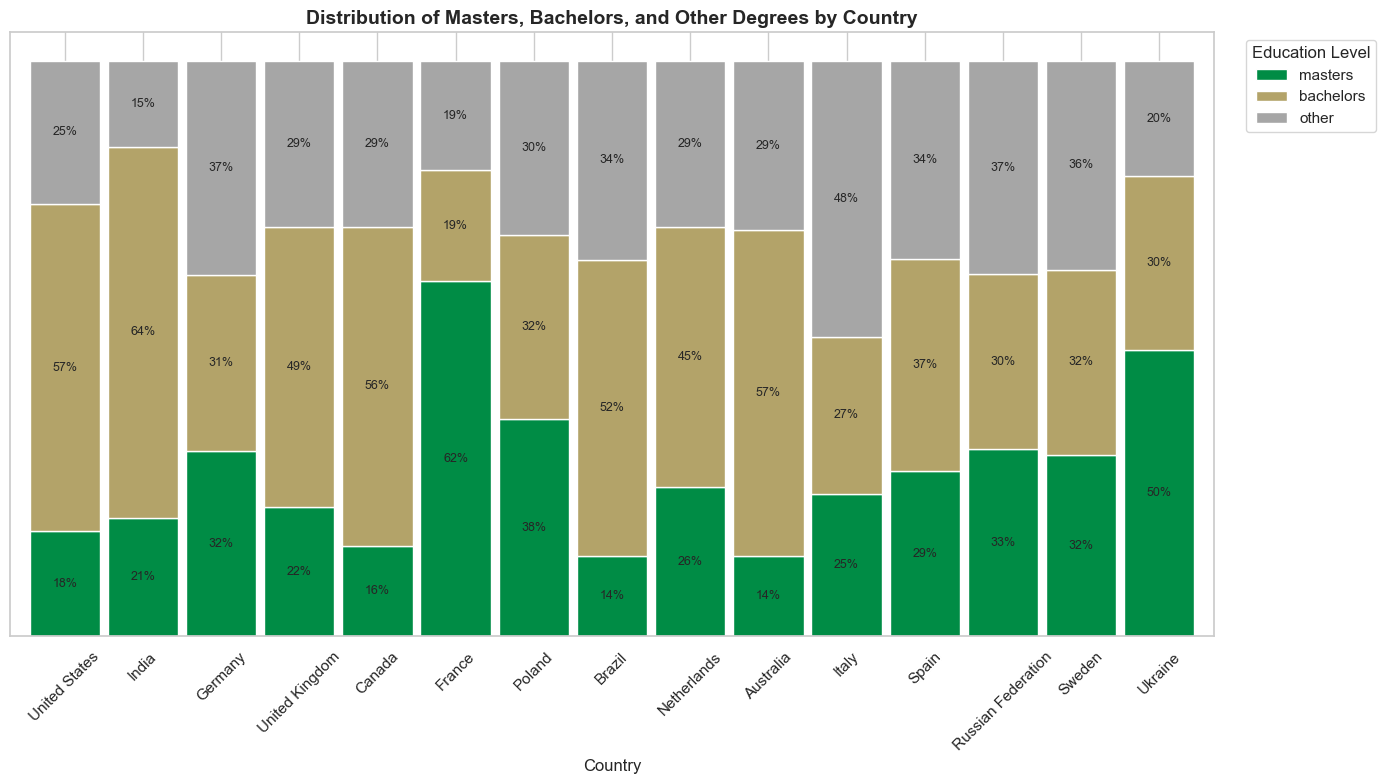

In [40]:
# Reorder columns to put 'masters' first, then 'bachelors', then 'other'
ordered_columns = ['masters', 'bachelors', 'other']
country_edu_pct_reordered = country_edu_pct_with_other[ordered_columns]

fig, ax = plt.subplots(figsize=(14, 8))

# Define custom colors for UNC Charlotte (green, gold, and a complementary color for 'other')
colors = ['#008C45', '#B3A369', '#A6A6A6'] # UNC Charlotte Green, UNC Charlotte Gold, and a grey for 'other'

country_edu_pct_reordered.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.9)

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('') # Remove y-axis label
ax.set_title('Distribution of Masters, Bachelors, and Other Degrees by Country', fontsize=14, fontweight='bold')
ax.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

ax.yaxis.set_visible(False) # Remove y-axis

# Add data labels
for container in ax.containers:
    labels = [f'{w:.0f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

### Global Map Visualization

In [47]:
df_2 = pd.read_csv("cleaned_developer_survey_data.csv")

df_2.head()

,Age,Gender,Country,Salary,Employment,Education,Years_Coding,year
0,39.5,Male,United Kingdom,51000.0,Employed (full-time),Bachelors degree,NaN,2018
1,21.0,Male,South Africa,260000.0,Employed (full-time),Some college/university study without earning a degree,7.0,2018
2,21.0,Male,United Kingdom,30000.0,Employed (full-time),Bachelors degree,7.0,2018
3,21.0,Male,United States of America,120000.0,Employed (full-time),Some college/university study without earning a degree,10.0,2018
4,39.5,Male,United States of America,250000.0,Employed (full-time),Some college/university study without earning a degree,NaN,2018


In [53]:
# Get country counts for all countries in the dataset
country_density = combined_consolidated_df['country'].value_counts().reset_index()
country_density.columns = ['country', 'count']

display(country_density.head(20))

,country,count
0,United States,152658
1,India,72378
2,Germany,51978
3,United Kingdom,46864
4,Canada,26954
5,France,22340
6,Poland,17108
7,Brazil,16764
8,Netherlands,15657
9,Australia,15134


In [54]:
# Set renderer for notebook
pio.renderers.default = 'notebook'

country_density_log = country_density.copy()
country_density_log['log_count'] = np.log10(country_density_log['count'])

In [55]:
country_density_log.head(20)

,country,count,log_count
0,United States,152658,5.183720
1,India,72378,4.859607
2,Germany,51978,4.715820
3,United Kingdom,46864,4.670839
4,Canada,26954,4.430623
5,France,22340,4.349083
6,Poland,17108,4.233199
7,Brazil,16764,4.224378
8,Netherlands,15657,4.194709
9,Australia,15134,4.179954


In [ ]:
# First, check the max count in your data
print(f"Max count: {country_density['count'].max()}")
print(f"Min count: {country_density['count'].min()}")

# Create bins based on actual data range
# Use np.inf for the last bin to capture all values above 50K
count_bins = [0, 100, 500, 1000, 5000, 10000, 50000, np.inf]
count_labels = ['<100', '100-500', '500-1K', '1K-5K', '5K-10K', '10K-50K', '>50K']

country_density_binned = country_density.copy()
country_density_binned['bin'] = pd.cut(country_density_binned['count'], 
                                        bins=count_bins, 
                                        labels=count_labels, 
                                        include_lowest=True)

# Create color map for raw counts - MUST match count_labels exactly
count_color_map = {
    '<100': '#deebf7',      # Lightest
    '100-500': '#c6dbef',
    '500-1K': '#9ecae1',
    '1K-5K': '#6baed6',
    '5K-10K': '#4292c6',
    '10K-50K': '#2171b5',
    '>50K': '#08519c'       # Darkest
}

fig_raw = px.choropleth(country_density_binned,
                        locations='country',
                        locationmode='country names',
                        color='bin',
                        hover_name='country',
                        hover_data={'count': ':,', 'country': False, 'bin': False},
                        color_discrete_map=count_color_map,
                        category_orders={'bin': count_labels},
                        title='Robinson Projection (Raw Count) - Binned Categories')

fig_raw.update_layout(
    geo=dict(
        projection_type='robinson',
        showcoastlines=True,
        coastlinecolor='DarkGray',
        showland=True,
        landcolor='lightgray'
    ),
    height=600,
    title_font_size=16,
    title_x=0.5
)

fig_raw

In [ ]:
# Create bins for better color distribution - more bins for finer gradation
bins = [0, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.25, 4.5, 5, 6]
labels = ['<10', '10-32', '32-100', '100-316', '316-1K', '1K-3.2K', '3.2K-5K', '5K-10K', '10K-32K', '32K-100K', '>100K']

country_density_log['bin'] = pd.cut(country_density_log['log_count'], bins=bins, labels=labels, include_lowest=True)

# Create a custom color map from light to dark blue
color_map = {
    '<10': '#deebf7',
    '10-32': '#c6dbef',
    '32-100': '#9ecae1',
    '100-316': '#6baed6',
    '316-1K': '#4292c6',
    '1K-3.2K': '#2171b5',
    '3.2K-5K': '#08519c',
    '5K-10K': '#08306b',
    '10K-32K': '#041e42',
    '32K-100K': '#021020',
    '>100K': '#000000'
}

fig5 = px.choropleth(country_density_log,
                     locations='country',
                     locationmode='country names',
                     color='bin',
                     hover_name='country',
                     hover_data={'count': ':,', 'country': False, 'bin': False},
                     color_discrete_map=color_map,  # Changed this line
                     category_orders={'bin': labels},
                     title='Robinson Projection (Log Scale) - Binned Categories')

fig5.update_layout(
    geo=dict(
        projection_type='robinson',
        showcoastlines=True,
        coastlinecolor='DarkGray',
        showland=True,
        landcolor='lightgray'
    ),
    height=600,
    title_font_size=16,
    title_x=0.5
)

fig5